# Testing various models

In the previous notebooks, we've tried Ott's model. In this one, I'm trying a few other to try to wrap my mind around the data. To keep things simple, I don't implement any state abstraction. 

## Compute decisions under optimal plan

In [53]:
import numpy as np
import pandas as pd
import os
from scipy.stats import zscore
from stabst.utils import plot_state_matrix, beh_barplot, abstract2ground_value
from scipy.special import expit
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import arviz as az
import pymc as pm

# ===================================================================================
# Prepare the data:
# Download data from Florian's repo:
data = pd.read_csv("../data/raw_data/all_participants_data.csv", on_bad_lines='skip')
# Remove nans:
data = data.dropna()
# Flip responses: 1 = accept:
data["response"] = np.abs(data["response"] - 1)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Remove the 
# Get subject IDs:
subj_idx_raw, subj_labels = pd.factorize(data["vpn"])
coords = {
    "observation": np.arange(len(data)),
    "subject": subj_labels,
}

transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]
subj_idx_raw, subj_labels = pd.factorize(data["vpn"])

In [54]:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 1
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()
R_full = task_mdp.expected_return(task_mdp.greedy_policy(Q_full), initial_energy=3)
# Get the decision value:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
mdl_sim_resps = []
decision_match = []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
    # Simulate data according to that plan:
    mdl_sim_resps.append(np.random.binomial(1, expit(dv[task.s2i[(e, o, cc, fc, t)]])))
    decision_match.append(1 - np.abs(trial.response - mdl_sim_resps[-1]))
data[f'DV'] = dv_trials


# Model 1: separate regressor for different offers

Based on the look of the data, it seems that participants operate under three different regimes based on the offer:
- Always accept if possible when offer is high (offer 4)
- Always reject when offer is low (offer 1)
- For intermediary offers, act in a state dependent manner

In other words, it would seem that for intermediary offer, where the decision is much less clear, participants engage in forward planning, considering each aspects of each state to determine their action. We will fit a model following this intuition

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 54 seconds.


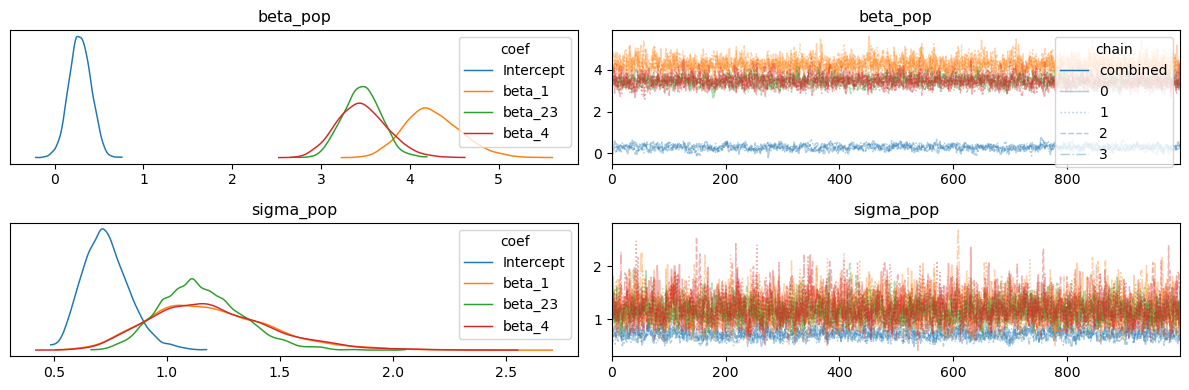

In [55]:
# Set coordinates
coords = {
    "subject": subj_labels,
    "coef": ["Intercept", "beta_1", "beta_23", "beta_4"],
}
traces = {}
with pm.Model(coords=coords) as mdl1:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data["DV"])
    is_1 = pm.Data("is_1", data["is_1"])
    is_23 = pm.Data("is_23", data["is_23"])
    is_4 = pm.Data("is_4", data["is_4"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] +
                             beta_sub[subj_idx, 1] * is_1 * dv +
                             beta_sub[subj_idx, 2] * is_23 * dv +
                             beta_sub[subj_idx, 3] * is_4 * dv
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)
    traces['mdl1'] =  pm.sample(1000, tune=1000, target_acceptance=0.95, idata_kwargs={"log_likelihood": True})
    data['p(y=1|y_obs, M1)'] = traces['mdl1'].posterior.p.mean(dim=["chain", "draw"])


# plot the trace of the none abstracted model:
az.plot_trace(traces['mdl1'], var_names=["beta_pop", "sigma_pop"], combined=True, legend=True)
plt.tight_layout()


# Model 2
Adding an intercept to each of these parameters in case participants have an offset in their decision values that are dependent on the offer:

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 111 seconds.


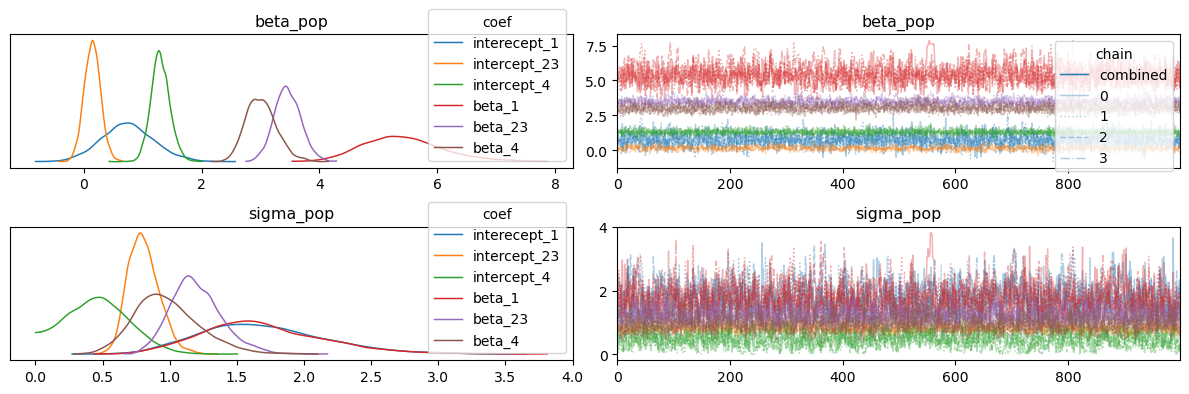

In [56]:
# Set coordinates
coords = {
    "subject": subj_labels,
    "coef": ["interecept_1", "intercept_23", "intercept_4", "beta_1", "beta_23", "beta_4"],
}
with pm.Model(coords=coords) as mdl1:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data["DV"])
    is_1 = pm.Data("is_1", data["is_1"])
    is_23 = pm.Data("is_23", data["is_23"])
    is_4 = pm.Data("is_4", data["is_4"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] * is_1 +
                             beta_sub[subj_idx, 1] * is_23 +
                             beta_sub[subj_idx, 2] * is_4 +
                             beta_sub[subj_idx, 3] * is_1 * dv +
                             beta_sub[subj_idx, 4] * is_23 * dv +
                             beta_sub[subj_idx, 5] * is_4 * dv
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)
    traces['mdl2'] =  pm.sample(1000, tune=1000, target_acceptance=0.95, idata_kwargs={"log_likelihood": True})
    data['p(y=1|y_obs, M2)'] = traces['mdl2'].posterior.p.mean(dim=["chain", "draw"])


# plot the trace of the none abstracted model:
az.plot_trace(traces['mdl2'], var_names=["beta_pop", "sigma_pop"], combined=True, legend=True)
plt.tight_layout()


# Model 3
Participants behaviour seem to deviate from the ideal plan in the ceiling and flooring conditions. When they have max energy, they tend to accept even when the optimal plan would recommend not to. We will fit a model to explore that behaviour

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 106 seconds.


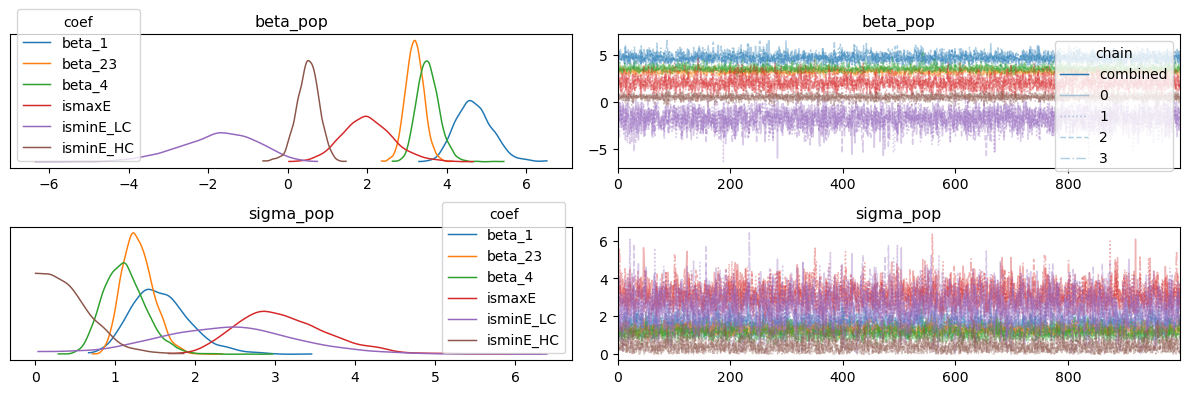

In [57]:
# Set coordinates
coords = {
    "subject": subj_labels,
    "coef": ["beta_1", "beta_23", "beta_4", "ismaxE", "isminE_LC", "isminE_HC"],
}
with pm.Model(coords=coords) as mdl1:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data["DV"])
    is_1 = pm.Data("is_1", data["is_1"])
    is_23 = pm.Data("is_23", data["is_23"])
    is_4 = pm.Data("is_4", data["is_4"])
    is_maxE = pm.Data("is_maxE", data["is_full_energy"])
    is_minE_LC = pm.Data("is_minE_LC", data["is_low_energy_LC"])
    is_minE_HC = pm.Data("is_minE_HC", data["is_low_energy_HC"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] * is_1 * dv +
                             beta_sub[subj_idx, 1] * is_23 * dv +
                             beta_sub[subj_idx, 2] * is_4 * dv +
                             beta_sub[subj_idx, 3] * is_maxE +
                             beta_sub[subj_idx, 4] * is_minE_LC +
                             beta_sub[subj_idx, 5] * is_minE_HC
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)
    traces['mdl3'] =  pm.sample(1000, tune=1000, target_acceptance=0.95, idata_kwargs={"log_likelihood": True})
    data['p(y=1|y_obs, M3)'] = traces['mdl3'].posterior.p.mean(dim=["chain", "draw"])


# plot the trace of the none abstracted model:
az.plot_trace(traces['mdl3'], var_names=["beta_pop", "sigma_pop"], combined=True, legend=True)
plt.tight_layout()


# Model 4: Ott's planning model

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 93 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


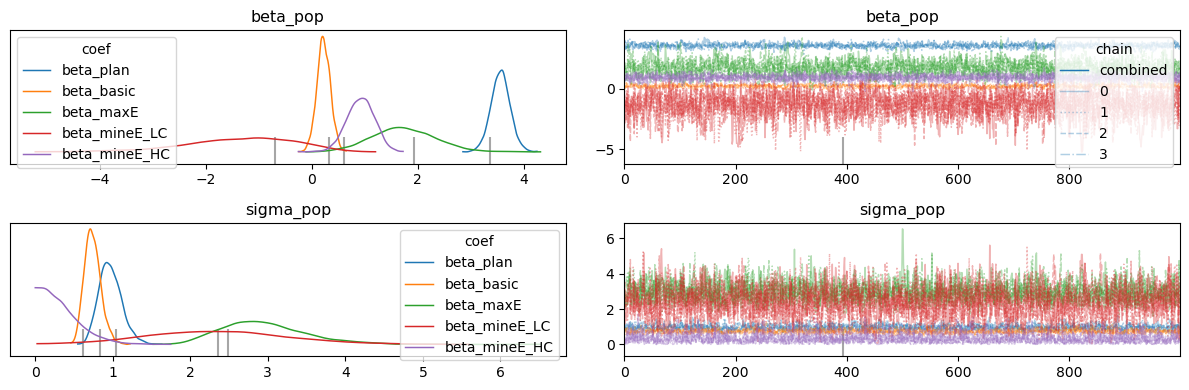

In [58]:
coords = {
    "subject": subj_labels,
    "coef": ["beta_plan", "beta_basic", "beta_maxE", "beta_mineE_LC", "beta_mineE_HC"],
}

with pm.Model(coords=coords) as hierarchical_binomial_regression:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data["DV"])
    is_basic = pm.Data("is_basic", data["is_basic"])
    is_maxE = pm.Data("is_maxE", data["is_full_energy"])
    is_minE_LC = pm.Data("is_minE_LC", data["is_low_energy_LC"])
    is_minE_HC = pm.Data("is_minE_HC", data["is_low_energy_HC"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] * dv +
                             beta_sub[subj_idx, 1] * is_basic +
                             beta_sub[subj_idx, 2] * is_maxE +
                             beta_sub[subj_idx, 3] * is_minE_LC +
                             beta_sub[subj_idx, 4] * is_minE_HC
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)
    traces['mdl4'] =  pm.sample(1000, tune=1000, target_acceptance=0.95, idata_kwargs={"log_likelihood": True})
    data['p(y=1|y_obs, M4)'] = traces['mdl4'].posterior.p.mean(dim=["chain", "draw"])

# plot the trace of the none abstracted model:
az.plot_trace(traces['mdl4'], var_names=["beta_pop", "sigma_pop"], combined=True, legend=True)
plt.tight_layout()


# Ott hybrid model

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 155 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


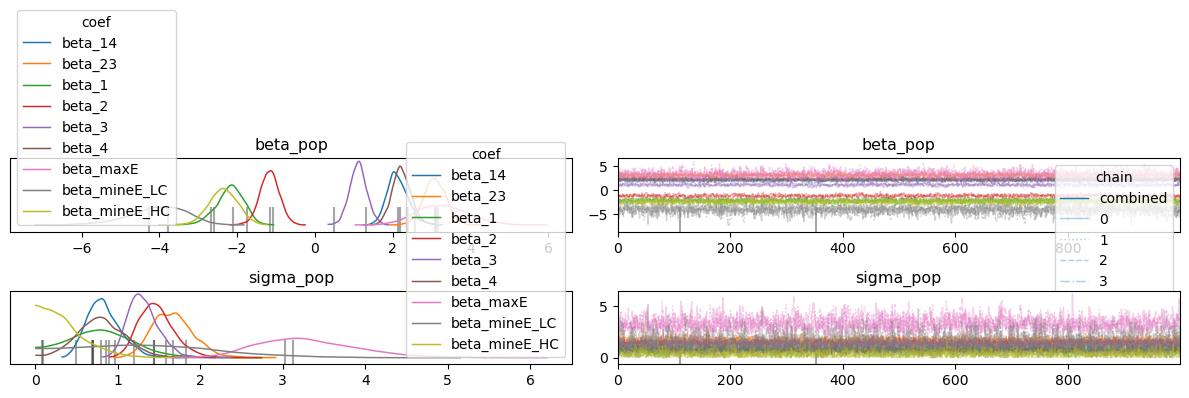

In [59]:
coords = {
    "subject": subj_labels,
    "coef": ["beta_14", "beta_23", "beta_1", "beta_2", "beta_3", "beta_4", "beta_maxE", "beta_mineE_LC", "beta_mineE_HC"],
}

with pm.Model(coords=coords) as hierarchical_binomial_regression:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data["DV"])
    is_1 = pm.Data("is_1", data["is_1"])
    is_2 = pm.Data("is_2", data["is_2"])
    is_3 = pm.Data("is_3", data["is_3"])
    is_4 = pm.Data("is_4", data["is_4"])
    is_14 = pm.Data("is_14", data["is_14"])
    is_23 = pm.Data("is_23", data["is_23"])
    is_basic = pm.Data("is_basic", data["is_basic"])
    is_maxE = pm.Data("is_maxE", data["is_full_energy"])
    is_minE_LC = pm.Data("is_minE_LC", data["is_low_energy_LC"])
    is_minE_HC = pm.Data("is_minE_HC", data["is_low_energy_HC"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] * dv * is_14 +
                             beta_sub[subj_idx, 1] * dv * is_23 +
                             beta_sub[subj_idx, 2] * is_1 +
                             beta_sub[subj_idx, 3] * is_2 +
                             beta_sub[subj_idx, 4] * is_3 +
                             beta_sub[subj_idx, 5] * is_4 +
                             beta_sub[subj_idx, 6] * is_maxE +
                             beta_sub[subj_idx, 7] * is_minE_LC +
                             beta_sub[subj_idx, 8] * is_minE_HC
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)
    traces['mdl5'] =  pm.sample(1000, tune=1000, target_acceptance=0.95, idata_kwargs={"log_likelihood": True})
    data['p(y=1|y_obs, M5)'] = traces['mdl5'].posterior.p.mean(dim=["chain", "draw"])

# plot the trace of the none abstracted model:
az.plot_trace(traces['mdl5'], var_names=["beta_pop", "sigma_pop"], combined=True, legend=True)
plt.tight_layout()


# Test simple model:

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 108 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


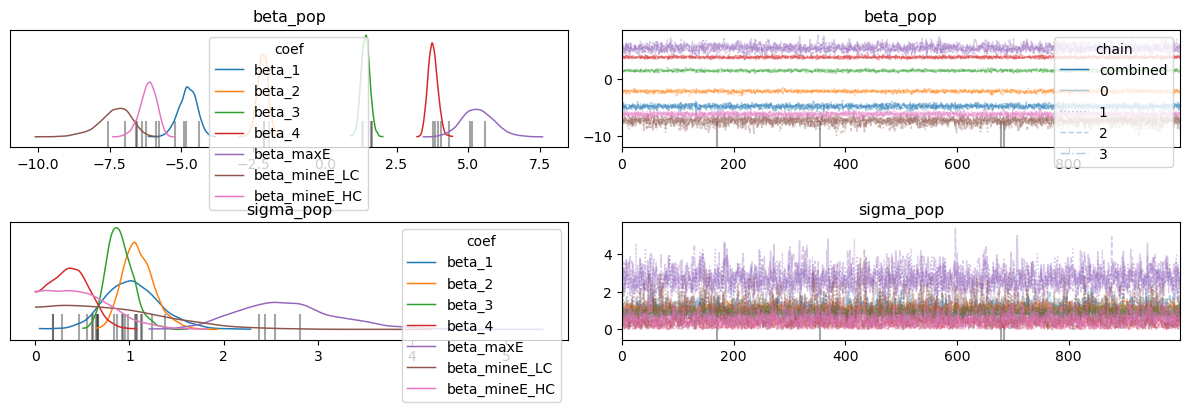

In [60]:
coords = {
    "subject": subj_labels,
    "coef": ["beta_1", "beta_2", "beta_3", "beta_4", "beta_maxE", "beta_mineE_LC", "beta_mineE_HC"],
}

with pm.Model(coords=coords) as hierarchical_binomial_regression:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data["DV"])
    is_1 = pm.Data("is_1", data["is_1"])
    is_2 = pm.Data("is_2", data["is_2"])
    is_3 = pm.Data("is_3", data["is_3"])
    is_4 = pm.Data("is_4", data["is_4"])
    is_14 = pm.Data("is_14", data["is_14"])
    is_23 = pm.Data("is_23", data["is_23"])
    is_basic = pm.Data("is_basic", data["is_basic"])
    is_maxE = pm.Data("is_maxE", data["is_full_energy"])
    is_minE_LC = pm.Data("is_minE_LC", data["is_low_energy_LC"])
    is_minE_HC = pm.Data("is_minE_HC", data["is_low_energy_HC"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] * is_1 +
                             beta_sub[subj_idx, 1] * is_2 +
                             beta_sub[subj_idx, 2] * is_3 +
                             beta_sub[subj_idx, 3] * is_4 +
                             beta_sub[subj_idx, 4] * is_maxE +
                             beta_sub[subj_idx, 5] * is_minE_LC +
                             beta_sub[subj_idx, 6] * is_minE_HC
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)
    traces['mdl6'] =  pm.sample(1000, tune=1000, target_acceptance=0.95, idata_kwargs={"log_likelihood": True})
    data['p(y=1|y_obs, M6)'] = traces['mdl6'].posterior.p.mean(dim=["chain", "draw"])

# plot the trace of the none abstracted model:
az.plot_trace(traces['mdl6'], var_names=["beta_pop", "sigma_pop"], combined=True, legend=True)
plt.tight_layout()


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 78 seconds.


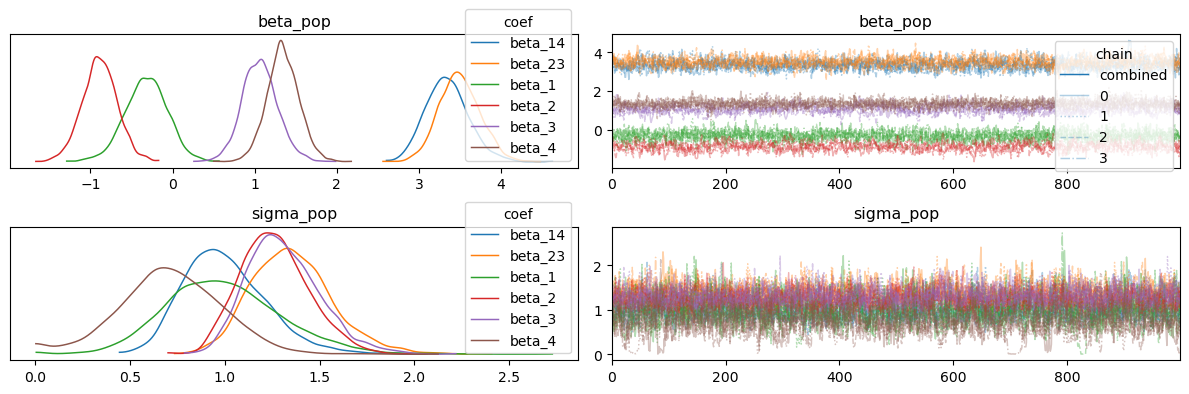

In [61]:
coords = {
    "subject": subj_labels,
    "coef": ["beta_14", "beta_23", "beta_1", "beta_2", "beta_3", "beta_4"],
}

with pm.Model(coords=coords) as hierarchical_binomial_regression:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data["DV"])
    is_1 = pm.Data("is_1", data["is_1"])
    is_2 = pm.Data("is_2", data["is_2"])
    is_3 = pm.Data("is_3", data["is_3"])
    is_4 = pm.Data("is_4", data["is_4"])
    is_14 = pm.Data("is_14", data["is_14"])
    is_23 = pm.Data("is_23", data["is_23"])
    is_basic = pm.Data("is_basic", data["is_basic"])
    is_maxE = pm.Data("is_maxE", data["is_full_energy"])
    is_minE_LC = pm.Data("is_minE_LC", data["is_low_energy_LC"])
    is_minE_HC = pm.Data("is_minE_HC", data["is_low_energy_HC"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] * dv * is_14 +
                             beta_sub[subj_idx, 1] * dv * is_23 +
                             beta_sub[subj_idx, 2] * is_1 +
                             beta_sub[subj_idx, 3] * is_2 +
                             beta_sub[subj_idx, 4] * is_3 +
                             beta_sub[subj_idx, 5] * is_4 
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)
    traces['mdl7'] =  pm.sample(1000, tune=1000, target_acceptance=0.95, idata_kwargs={"log_likelihood": True})
    data['p(y=1|y_obs, M7)'] = traces['mdl7'].posterior.p.mean(dim=["chain", "draw"])

# plot the trace of the none abstracted model:
az.plot_trace(traces['mdl7'], var_names=["beta_pop", "sigma_pop"], combined=True, legend=True)
plt.tight_layout()


# Compare the models
We can compare the models to find the one of best fit:

/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvr

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

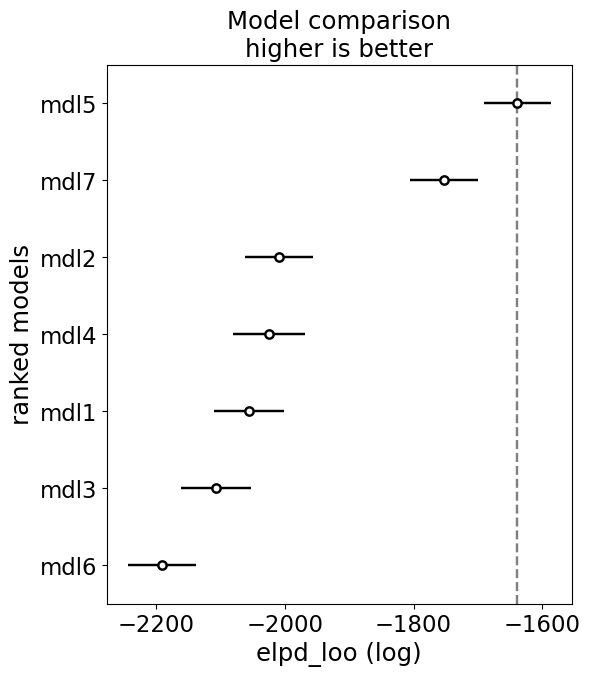

In [62]:
# Compare models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison)

## Plot results

(<Figure size 1200x800 with 17 Axes>,
 array([[<Axes: title={'center': 'Offer = 1'}, ylabel='cc=1, fc=1 \n Energy'>,
         <Axes: title={'center': 'Offer = 2'}>,
         <Axes: title={'center': 'Offer = 3'}>,
         <Axes: title={'center': 'Offer = 4'}>],
        [<Axes: ylabel='cc=1, fc=2 \n Energy'>, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='cc=2, fc=1 \n Energy'>, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='Trials', ylabel='cc=2, fc=2 \n Energy'>,
         <Axes: xlabel='Trials'>, <Axes: xlabel='Trials'>,
         <Axes: xlabel='Trials'>]], dtype=object))

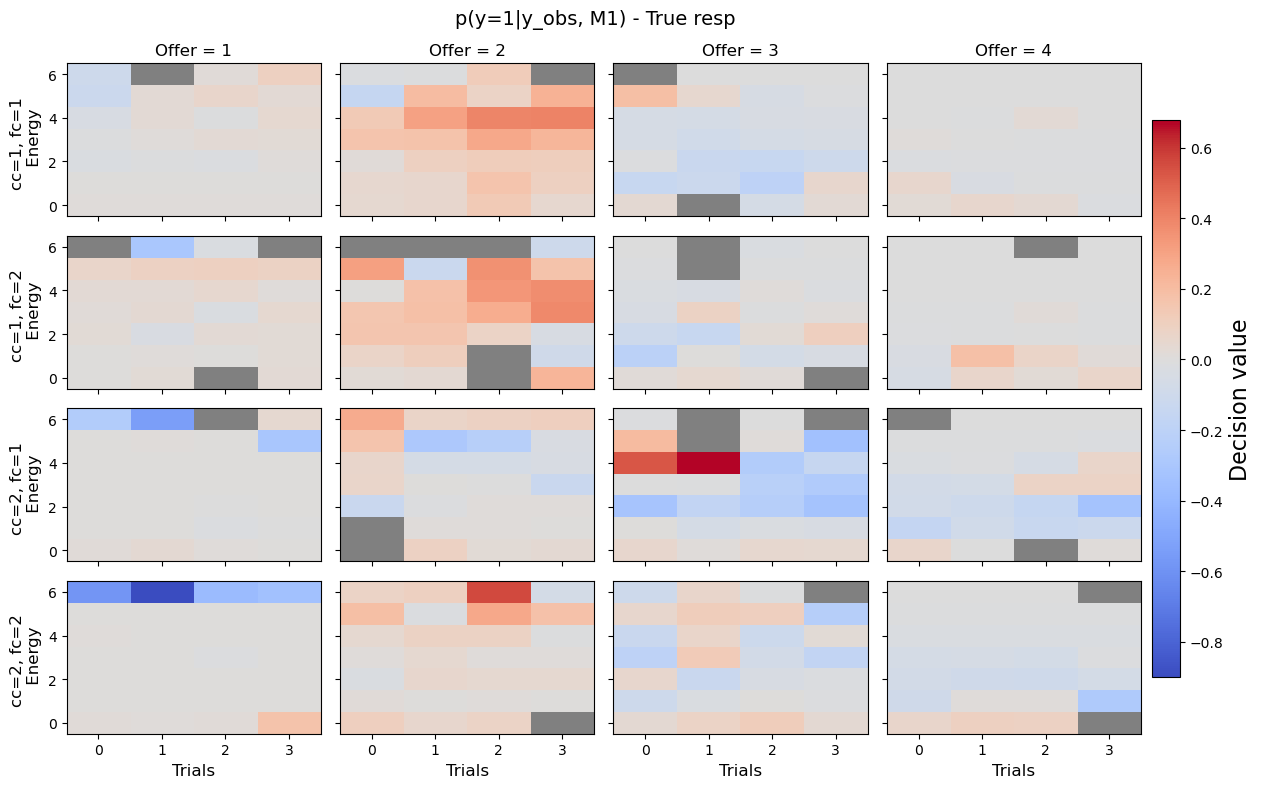

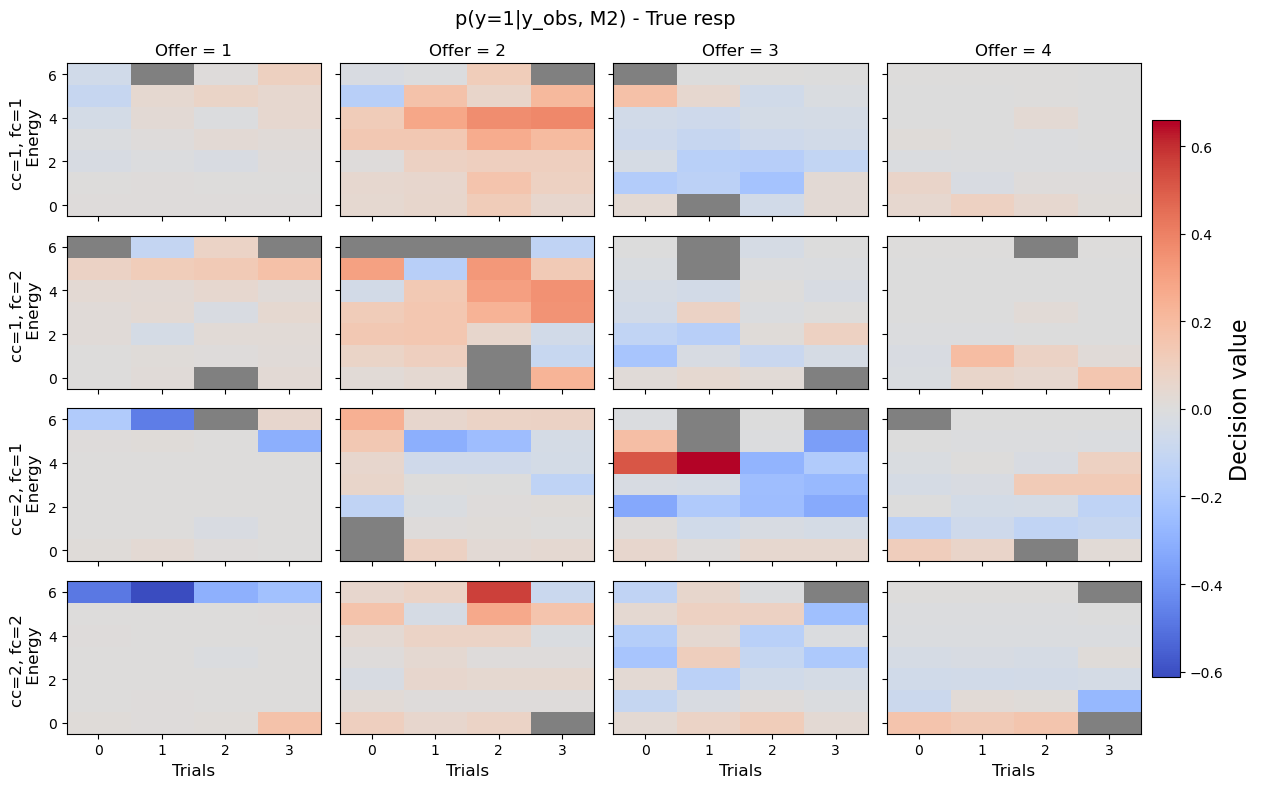

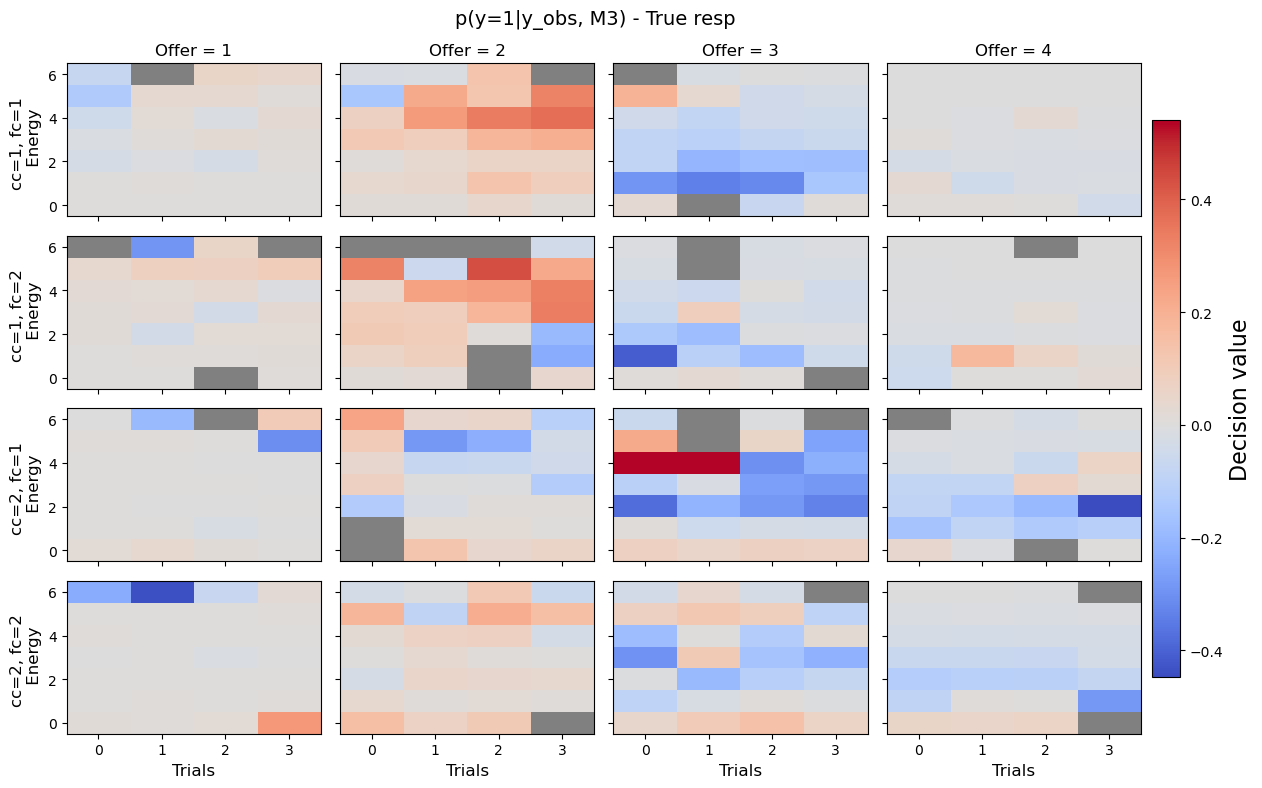

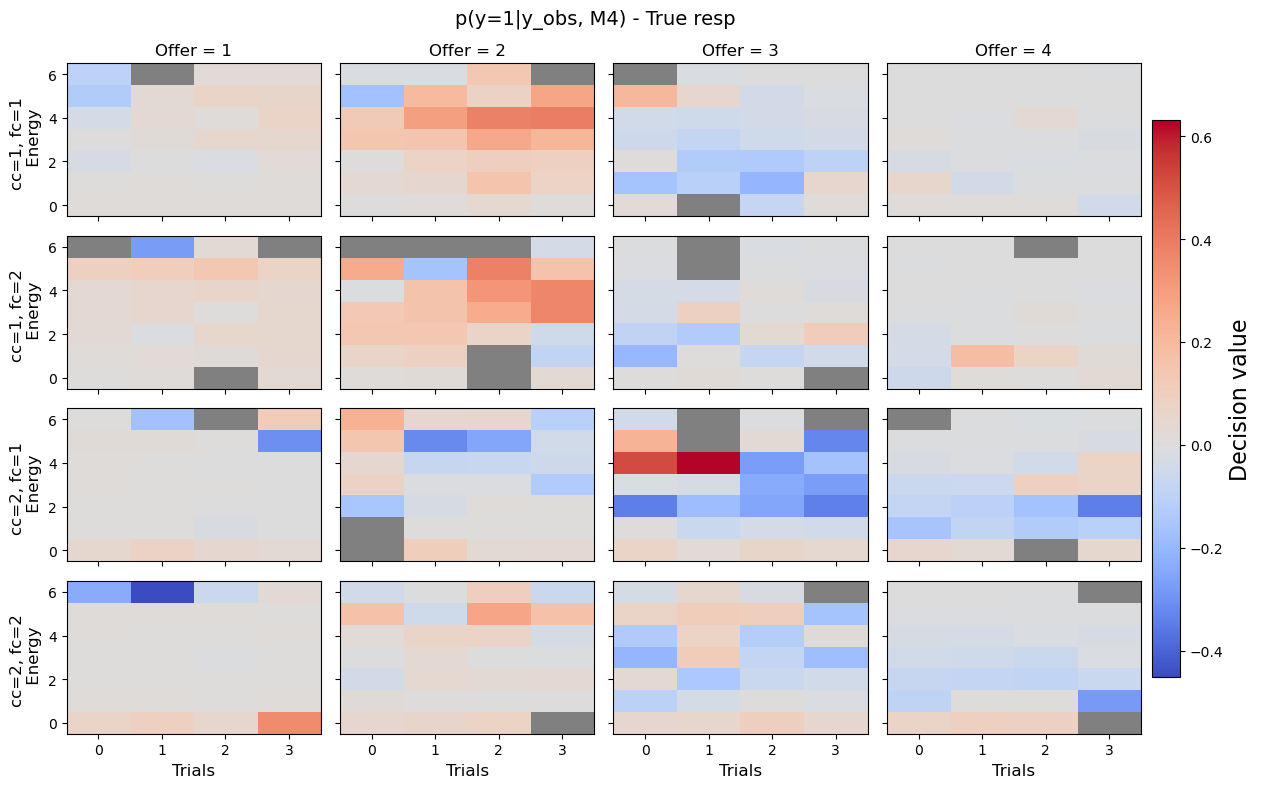

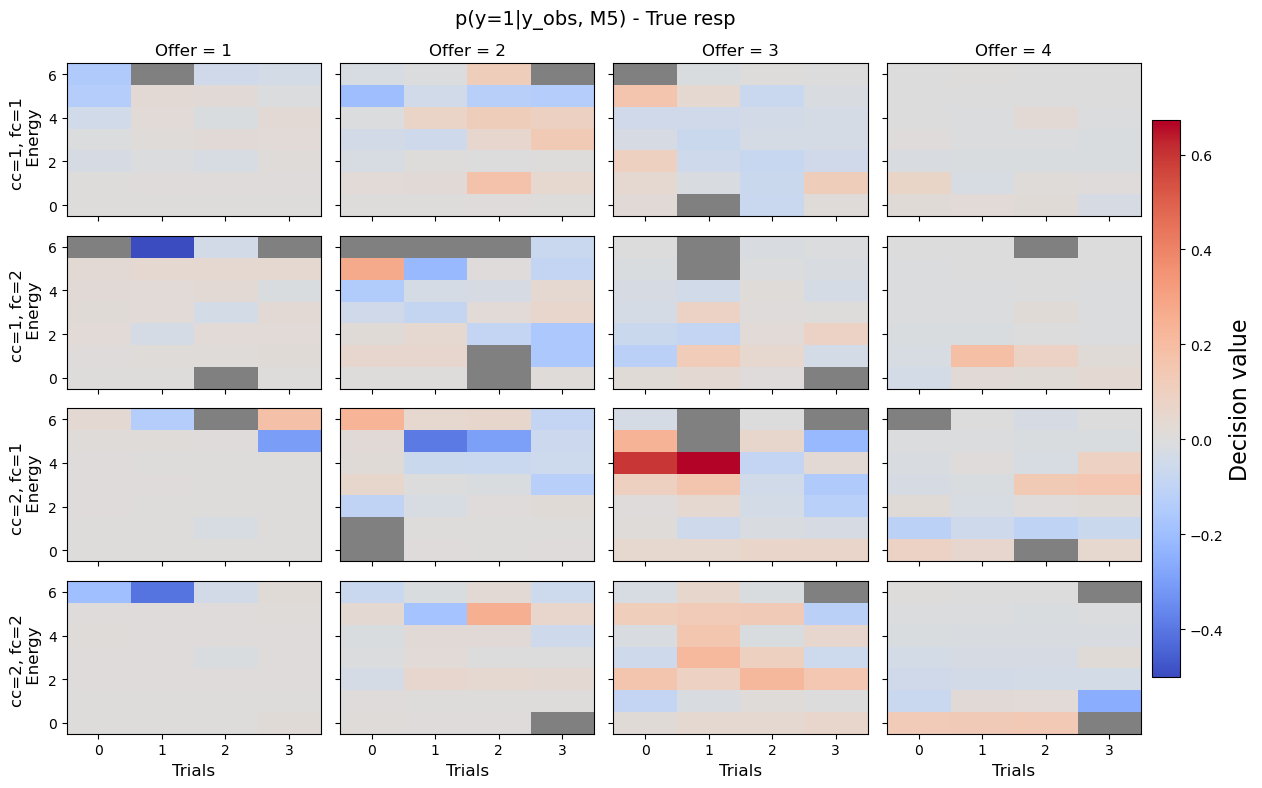

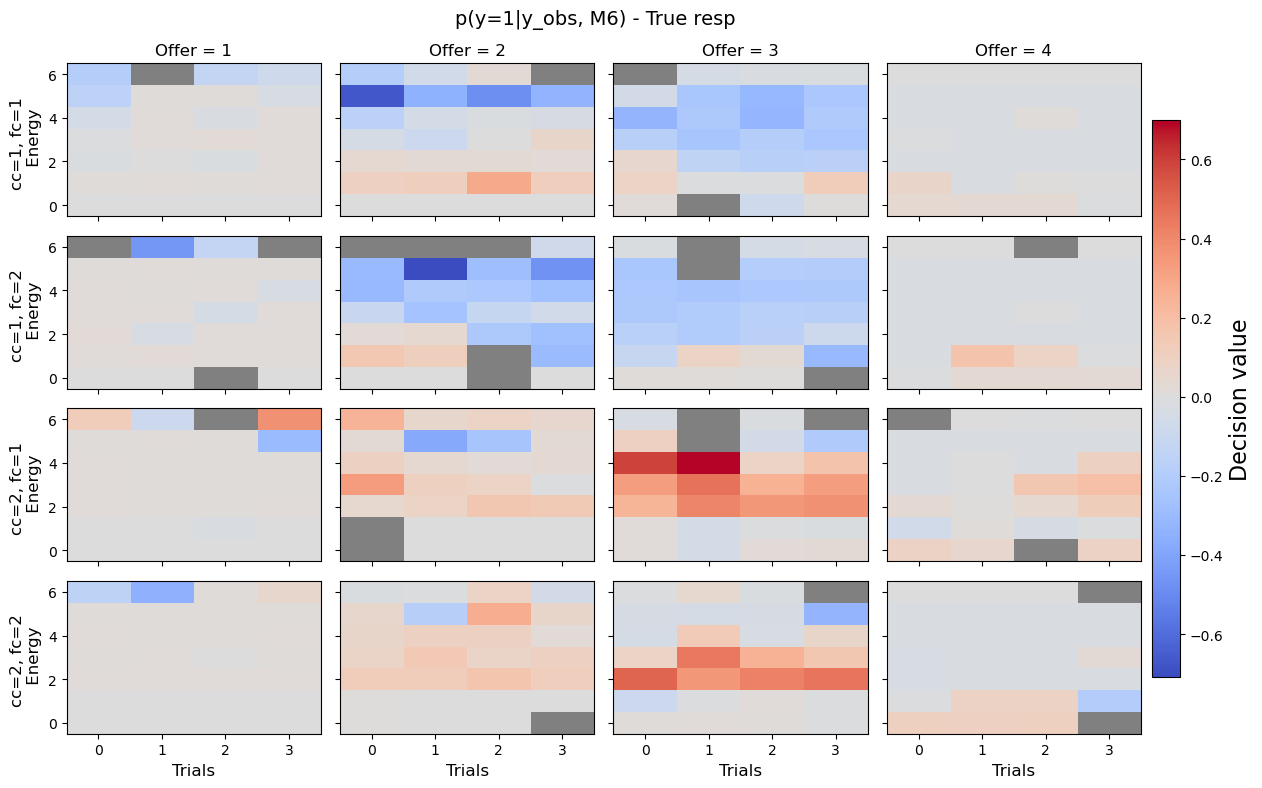

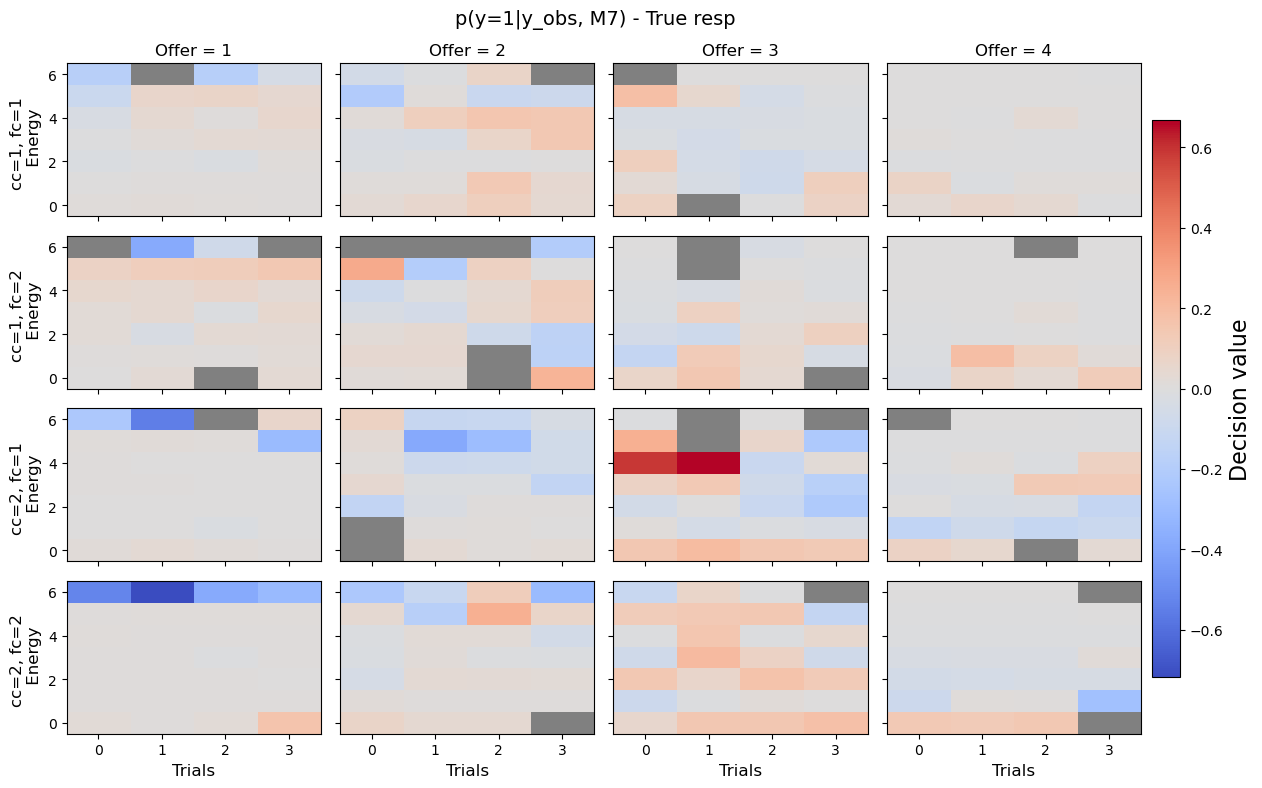

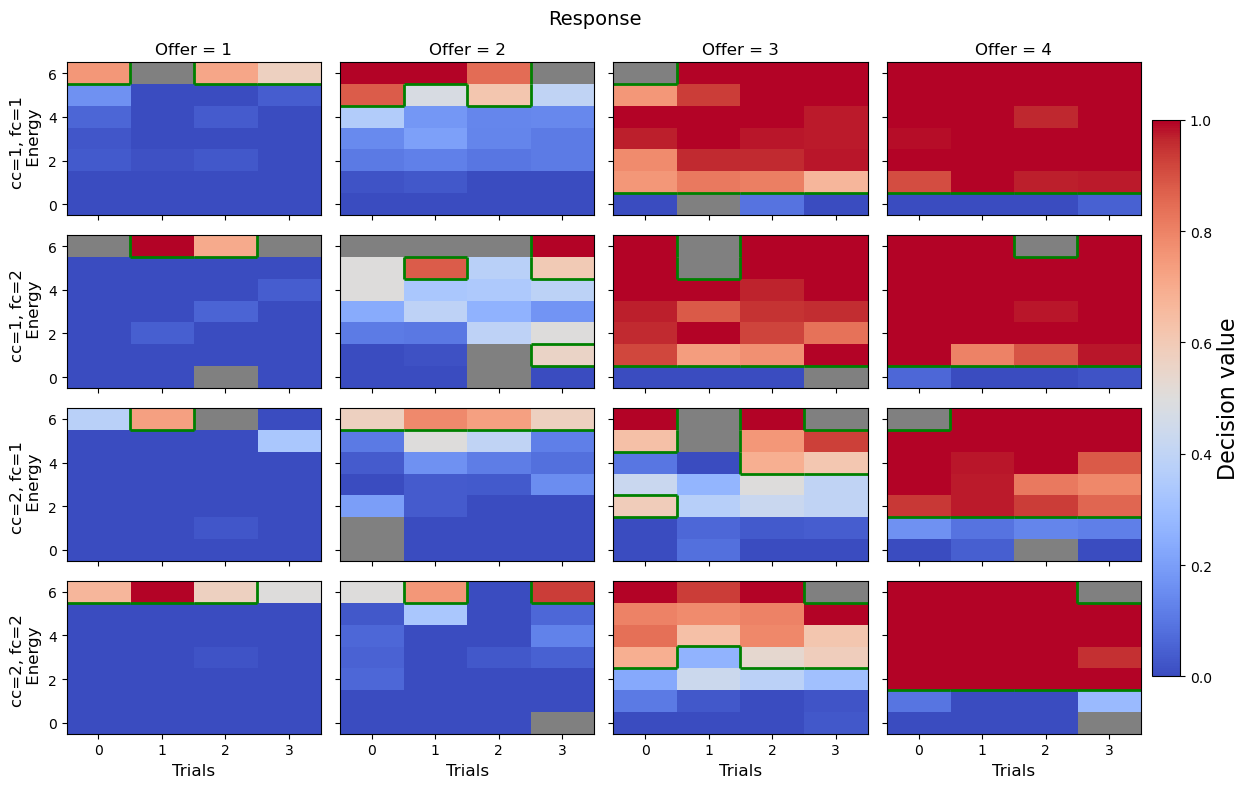

In [ ]:
state_cols = ["energy", "reward", "energy_cost", "fc", "trial"]
cmap = plt.get_cmap('coolwarm')
cmap.set_bad("grey")
mean_resp = [np.empty(len(task_mdp.states)) for i in [1, 2, 3, 4, 5, 6, 7]]
mean_resp_tru = np.empty(len(task_mdp.states))
for state in task_mdp.states:
    mean_resp_tru[task_mdp.s2i[*state]] = data.loc[(data[state_cols].to_numpy() == state).all(axis=1), 'response'].mean()
for i in [1, 2, 3, 4, 5, 6, 7]:
    for state in task_mdp.states:
        mean_resp[i-1][task_mdp.s2i[*state]] = data.loc[(data[state_cols].to_numpy() == state).all(axis=1), f'p(y=1|y_obs, M{i})'].mean()
    task_mdp.plot_dv(mean_resp[i-1] - mean_resp_tru, title=f'p(y=1|y_obs, M{i}) - True resp', tmax=4, cmap=cmap, cmap_midpoint=0, boundary_threshold=None, vmin=-1, vmax=1)
